Images loaded successfully.
Keypoints in Normal Image : 1000
Keypoints in Low-light Image : 1000
Good Matches : 10


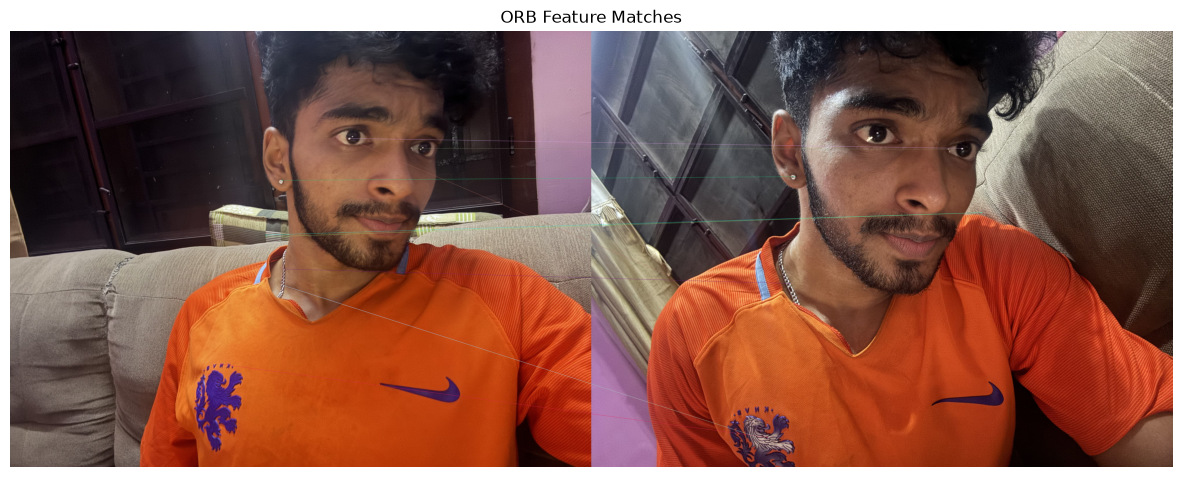

Homography Matrix
[[-6.81664050e-01 -9.55509060e-01  3.67061076e+03]
 [ 3.81097504e-01  1.89548318e-01 -7.70056588e+02]
 [-1.14297732e-04 -2.70114258e-04  1.00000000e+00]]


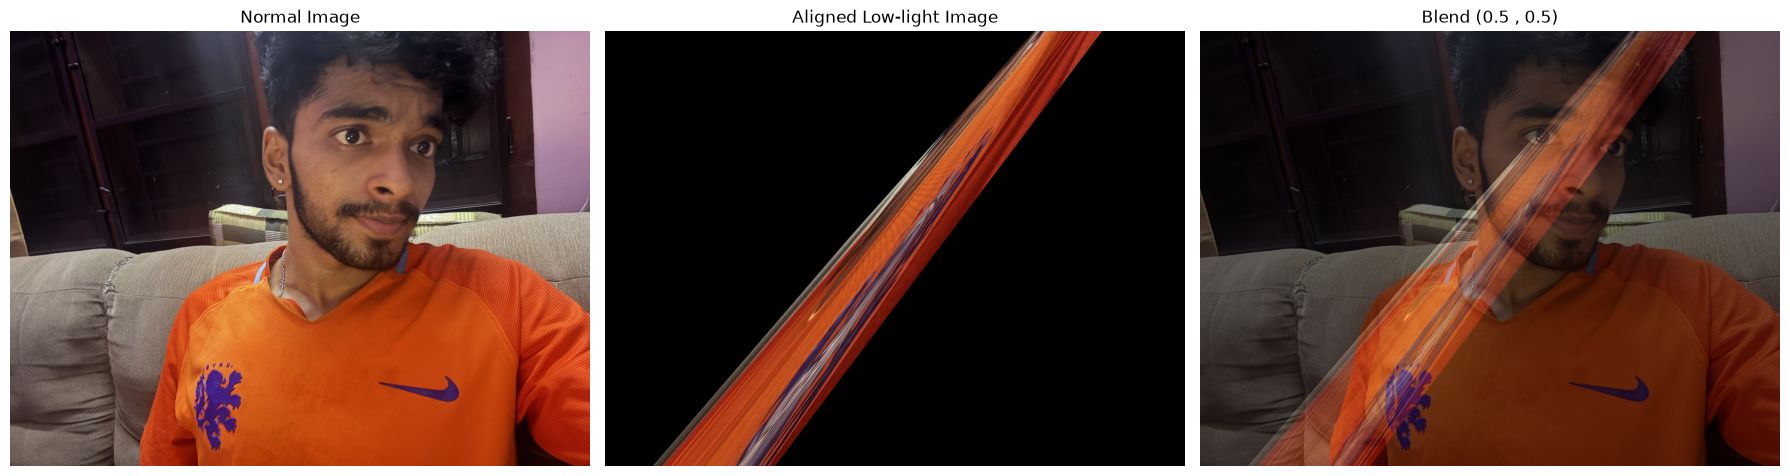

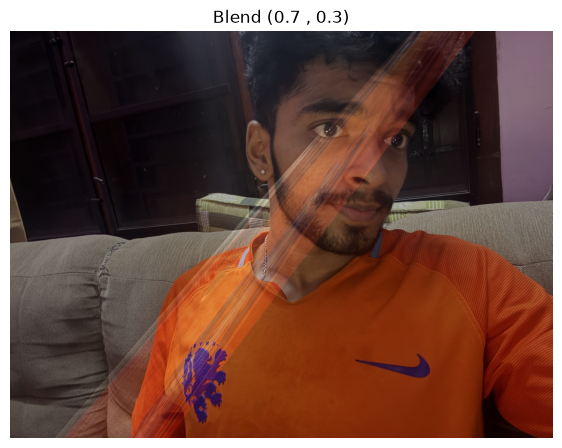

In [1]:
#Read Images
 #     ↓
#ORB Keypoint Detection
 #     ↓
#Descriptor Extraction
 #     ↓
#Feature Matching
 #     ↓
#Keep Good Matches
 #     ↓
#Estimate Homography
 #     ↓
#Warp Low-Light Image
 #     ↓
#Blend Images

# Task 2: Image Blending using Feature Matching

## Aim

#To align a low-light image with a normal-light image using ORB feature matching and homography estimation, and then blend both images using different weight combinations.

## Theory

#Feature matching is used to identify common points between two images of the same scene. ORB (Oriented FAST and Rotated BRIEF) detects keypoints and computes descriptors. These descriptors are matched using a Brute Force Matcher. A homography matrix is then estimated using RANSAC to align one image with another. Finally, the aligned images are blended using weighted averaging.

import cv2
import numpy as np
import matplotlib.pyplot as plt
img1 = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/normal.jpg")
img2 = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/lowlight.jpg")

if img1 is None or img2 is None:
    print("Check image paths.")
else:
    print("Images loaded successfully.")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(1000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Keypoints in Normal Image :", len(kp1))
print("Keypoints in Low-light Image :", len(kp2))

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good Matches :", len(good_matches))

matched_image = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches[:50],
    None,
    flags=2
)

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

src_pts = np.float32(
    [kp1[m.queryIdx].pt for m in good_matches]
).reshape(-1,1,2)

dst_pts = np.float32(
    [kp2[m.trainIdx].pt for m in good_matches]
).reshape(-1,1,2)

H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

print("Homography Matrix")
print(H)

height, width = img1.shape[:2]

aligned = cv2.warpPerspective(img2, H, (width, height))

blend1 = cv2.addWeighted(img1, 0.5, aligned, 0.5, 0)

blend2 = cv2.addWeighted(img1, 0.7, aligned, 0.3, 0)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Normal Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.title("Aligned Low-light Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(blend1, cv2.COLOR_BGR2RGB))
plt.title("Blend (0.5 , 0.5)")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(blend2, cv2.COLOR_BGR2RGB))
plt.title("Blend (0.7 , 0.3)")
plt.axis("off")
plt.show()

## Observation

#The ORB detector successfully extracted keypoints from both images. After applying Lowe's ratio test,good matches** were obtained.

#The homography matrix aligned the low-light image with the normal-light image reasonably well. Most regions overlapped correctly, although slight misalignment was visible near the image boundaries due to differences in camera position and lighting.

#Two blended images were generated using weight combinations of 0.5:0.5 and 0.7:0.3. The first blend gave equal importance to both images, while the second blend preserved more details from the normal-light image.

## Conclusion
#In this task, ORB feature matching was used to identify corresponding points between two images. A homography matrix was estimated to align the images, and the aligned images were blended using different weights. This demonstrated the use of feature matching and image registration in OpenCV.